# Validacion de Archivos SUMO

Verificacion de los archivos de configuracion generados en la Actividad 2:
- Red geometrica: `Simple_Intersection.net.xml`
- Demand vehicular: `loja_intersection_weibull.rou.xml`

In [1]:
import subprocess
import os
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
NET = os.path.join("..", "Simple_Intersection.net.xml")
ROU = os.path.join("loja_intersection_weibull.rou.xml")

print(f"Red: {NET} - Existe: {os.path.exists(NET)}")
print(f"Rutas: {ROU} - Existe: {os.path.exists(ROU)}")

Red: ../Simple_Intersection.net.xml - Existe: True
Rutas: loja_intersection_weibull.rou.xml - Existe: True


## 1. Validacion de la Red (.net.xml)

Se ejecuta SUMO con la red y las rutas para verificar que la topologia no tiene errores de conexion, carriles o velocidades.

In [3]:
sumo_cmd = [
    "sumo",
    "-n", NET,
    "-r", ROU,
    "--no-step-log",
    "--no-duration-log",
    "--time-to-teleport", "-1",
    "-W"
]

result = subprocess.run(sumo_cmd, capture_output=True, text=True, timeout=120)

if result.returncode == 0:
    print("Simulacion completada sin errores")
    if result.stderr:
        print(f"Advertencias: {result.stderr[:300]}")
    else:
        print("Sin advertencias")
else:
    print(f"Error: {result.stderr[:500]}")

Simulacion completada sin errores
Sin advertencias


## 2. Validacion de Rutas y Demanda

Se ejecuta la simulacion con salida FCD (Full Car Following Data) y tripinfo para analizar:
- Distribucion por tipo de vehiculo
- Distribucion por acceso (Oeste/Norte)
- Distribucion por destino (Este/Sur)
- Patron de llegadas Weibull

In [4]:
FCD_FILE = "validation_fcd.xml"
TRIPINFO_FILE = "validation_tripinfo.xml"

sumo_cmd_detail = [
    "sumo",
    "-n", NET,
    "-r", ROU,
    "--no-step-log",
    "--no-duration-log",
    "--time-to-teleport", "-1",
    "-W",
    "--fcd-output", FCD_FILE,
    "--tripinfo-output", TRIPINFO_FILE
]

result = subprocess.run(sumo_cmd_detail, capture_output=True, text=True, timeout=300)

if result.returncode == 0:
    print(f"FCD generado: {os.path.getsize(FCD_FILE)} bytes")
    print(f"Tripinfo generado: {os.path.getsize(TRIPINFO_FILE)} bytes")
else:
    print(f"Error: {result.stderr[:500]}")

FCD generado: 42319410 bytes
Tripinfo generado: 985400 bytes


## 3. Analisis de Resultados

In [5]:
tree = ET.parse(TRIPINFO_FILE)
root = tree.getroot()

trips = []
for trip in root.iter('tripinfo'):
    trips.append({
        'id': trip.get('id'),
        'depart': float(trip.get('depart', 0)),
        'departLane': trip.get('departLane', ''),
        'arrivalLane': trip.get('arrivalLane', ''),
        'duration': float(trip.get('duration', 0)),
        'routeLength': float(trip.get('routeLength', 0)),
        'waitingTime': float(trip.get('waitingTime', 0)),
        'timeLoss': float(trip.get('timeLoss', 0)),
        'vType': trip.get('vType', ''),
    })

df = pd.DataFrame(trips)
print(f"Total de vehiculos: {len(df)}")

Total de vehiculos: 2334


### 3.1 Distribucion por tipo de vehiculo

In [6]:
print("--- Distribucion por tipo ---")
print(df['vType'].value_counts())
print()
print("Porcentajes:")
print((df['vType'].value_counts() / len(df) * 100).round(2))

--- Distribucion por tipo ---
vType
car     1669
bus      552
moto     197
Name: count, dtype: int64

Porcentajes:
vType
car     69.02
bus     22.83
moto     8.15
Name: count, dtype: float64


### 3.2 Distribucion por acceso y destino

In [7]:
df['acceso'] = df['departLane'].apply(lambda x: 'Oeste (-E4)' if '-E4' in x else 'Norte (-E5)')
df['destino'] = df['arrivalLane'].apply(lambda x: 'Este (E3)' if 'E3' in x else 'Sur (E6)')

print("--- Distribucion por acceso ---")
print(df['acceso'].value_counts())
print()
print("--- Distribucion por destino ---")
print(df['destino'].value_counts())

--- Distribucion por acceso ---
acceso
Norte (-E5)    1240
Oeste (-E4)    1178
Name: count, dtype: int64

--- Distribucion por destino ---
destino
Sur (E6)     1235
Este (E3)    1183
Name: count, dtype: int64


### 3.3 Metricas de viaje

In [8]:
print("--- Metricas de viaje ---")
print(f"Tiempo de viaje promedio: {df['duration'].mean():.1f}s")
print(f"Tiempo de espera promedio: {df['waitingTime'].mean():.1f}s")
print(f"Tiempo perdido promedio: {df['timeLoss'].mean():.1f}s")
print(f"Longitud de ruta promedio: {df['routeLength'].mean():.1f}m")

--- Metricas de viaje ---
Tiempo de viaje promedio: 132.4s
Tiempo de espera promedio: 55.4s
Tiempo perdido promedio: 84.3s
Longitud de ruta promedio: 606.3m


### 3.4 Patron de llegadas (Weibull)

In [9]:
bins = [0, 600, 1200, 1800, 2400, 3000, 3600]
labels = ['0-10min', '10-20min', '20-30min', '30-40min', '40-50min', '50-60min']
df['intervalo'] = pd.cut(df['depart'], bins=bins, labels=labels)

print("--- Distribucion temporal (Weibull) ---")
print(df['intervalo'].value_counts().sort_index())
print()
print(f"Primer vehiculo: {df['depart'].min():.1f}s")
print(f"Ultimo vehiculo: {df['depart'].max():.1f}s")

--- Distribucion temporal (Weibull) ---
intervalo
0-10min      93
10-20min    450
20-30min    513
30-40min    484
40-50min    473
50-60min    405
Name: count, dtype: int64

Primer vehiculo: 112.0s
Ultimo vehiculo: 3600.0s


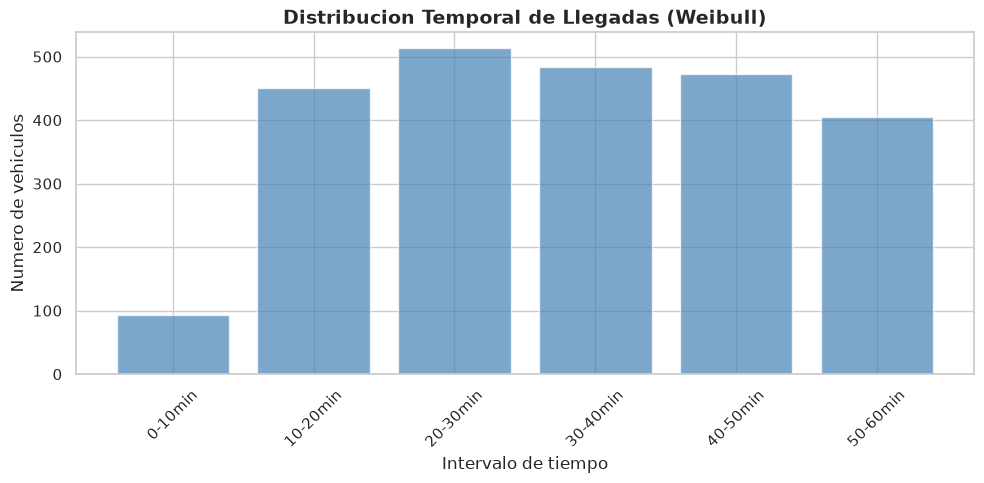

In [10]:
# Grafica del patron Weibull
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 5))

conteo = df['intervalo'].value_counts().sort_index()
plt.bar(conteo.index, conteo.values, color='steelblue', alpha=0.7)
plt.title('Distribucion Temporal de Llegadas (Weibull)', fontsize=14, fontweight='bold')
plt.xlabel('Intervalo de tiempo')
plt.ylabel('Numero de vehiculos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Archivos validados correctamente:
- **Red (.net.xml):** Sin errores de conexion
- **Rutas (.rou.xml):** Vehiculos circulan por aristas correctas
- **Demanda Weibull:** Patron de campana asimetrica verificado

In [11]:
# Limpiar archivos temporales
os.remove(FCD_FILE)
os.remove(TRIPINFO_FILE)
print("Archivos temporales eliminados")

Archivos temporales eliminados
